In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [2]:
import numpy as np

import torch
import pynvml

from hw1.models import SmallCNN
from hw1.measure_helpers import collect_measurements

In [3]:
model = SmallCNN()

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False
model = model.cuda().eval()

In [4]:
image_sizes = np.array([32, 64, 128, 224, 256, 384, 512])
batches = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])

# Все сочетания S и B.
s_grid, b_grid = np.meshgrid(
    image_sizes, batches, indexing="ij"
)
sizes = s_grid.ravel()
batch_sizes = b_grid.ravel()

In [5]:
from hw1.equations import memory


@torch.inference_mode()
def measure_memory(model, image_size, batch, warmup=5):
    model.eval()
    device = next(model.parameters()).device

    x = torch.randn(int(batch), 3, int(image_size), int(
        image_size), device=device, dtype=torch.float32,)

    for _ in range(warmup):
        output = model(x)
        del output  # Не оставляем выход прогрева в памяти.

    torch.cuda.synchronize(device)
    torch.cuda.reset_peak_memory_stats(device)

    output = model(x)
    torch.cuda.synchronize(device)

    peak_bytes = torch.cuda.max_memory_allocated(device)

    del output, x
    return float(peak_bytes)


def collect_measurements_memory(model, sizes, batch_sizes, log=False):
    rows = []

    for s, b in zip(sizes, batch_sizes, strict=True):
        measured = measure_memory(model, s, b)
        rows.append((s, b, measured))

        if log:
            print(
                f"S={s:3d}, B={b:2d}: "
                f"{measured / 2**20:.3f} MiB"
            )

    return np.asarray(rows, dtype=float)

In [6]:
import matplotlib.pyplot as plt


def plot(sizes, batch_sizes, measured, func, y_label, path_save):
    unique_batches = np.unique(batch_sizes)
    ncols = 2
    nrows = (len(unique_batches) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False,)

    for ax, batch in zip(axes.flat, unique_batches):
        ids = np.flatnonzero(batch_sizes == batch)
        ids = ids[np.argsort(sizes[ids])]

        ax.scatter(sizes[ids], measured[ids], label="Measured")

        s_curve = np.arange(int(sizes[ids].min()), int(sizes[ids].max()) + 1, 16)
        ax.plot(s_curve, np.asarray(func(s_curve, int(batch))), label="Predicted",)

        ax.set_title(f"Batch size B = {int(batch)} images")
        ax.set_xlabel("Image side S (pixels)")
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.3)
        ax.legend()

    for ax in list(axes.flat)[len(unique_batches):]:
        ax.set_visible(False)

    fig.tight_layout()
    fig.savefig(path_save, dpi=150)
    plt.show()

In [7]:
from pathlib import Path
import pandas as pd


def save_measurements_csv(path, sizes, batch_sizes, values, metric):
    columns = ["S", "B", "latency", "memory", "energy"]

    if metric not in {"latency", "memory", "energy"}:
        raise ValueError(f"Unknown metric: {metric}")

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.exists():
        df = pd.read_csv(path)
    else:
        df = pd.DataFrame(columns=columns)

    if df.duplicated(["S", "B"]).any():
        raise ValueError("В CSV есть повторяющиеся пары (S, B)")

    # Разрешаем значения memory вроде 'OOM'.
    df[metric] = df[metric].astype(object)

    for s, b, value in zip(
        sizes, batch_sizes, values, strict=True
    ):
        mask = (df["S"] == int(s)) & (df["B"] == int(b))

        if mask.any():
            df.loc[mask, metric] = value
        else:
            row = {
                "S": int(s),
                "B": int(b),
                metric: value,
            }
            df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

    df = df[columns].sort_values(["S", "B"])
    temporary = path.with_name(path.name + ".tmp")
    df.to_csv(temporary, index=False)
    temporary.replace(path)

In [8]:
PATH_SAVE = './results/figures'
PATH_CSV = './results/measurements.csv'

## Memory

[W926 18:36:05.933263170 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 1073741824 bytes (free: 148504576, total: 12337348608).


Memory MAPE: 53.5%


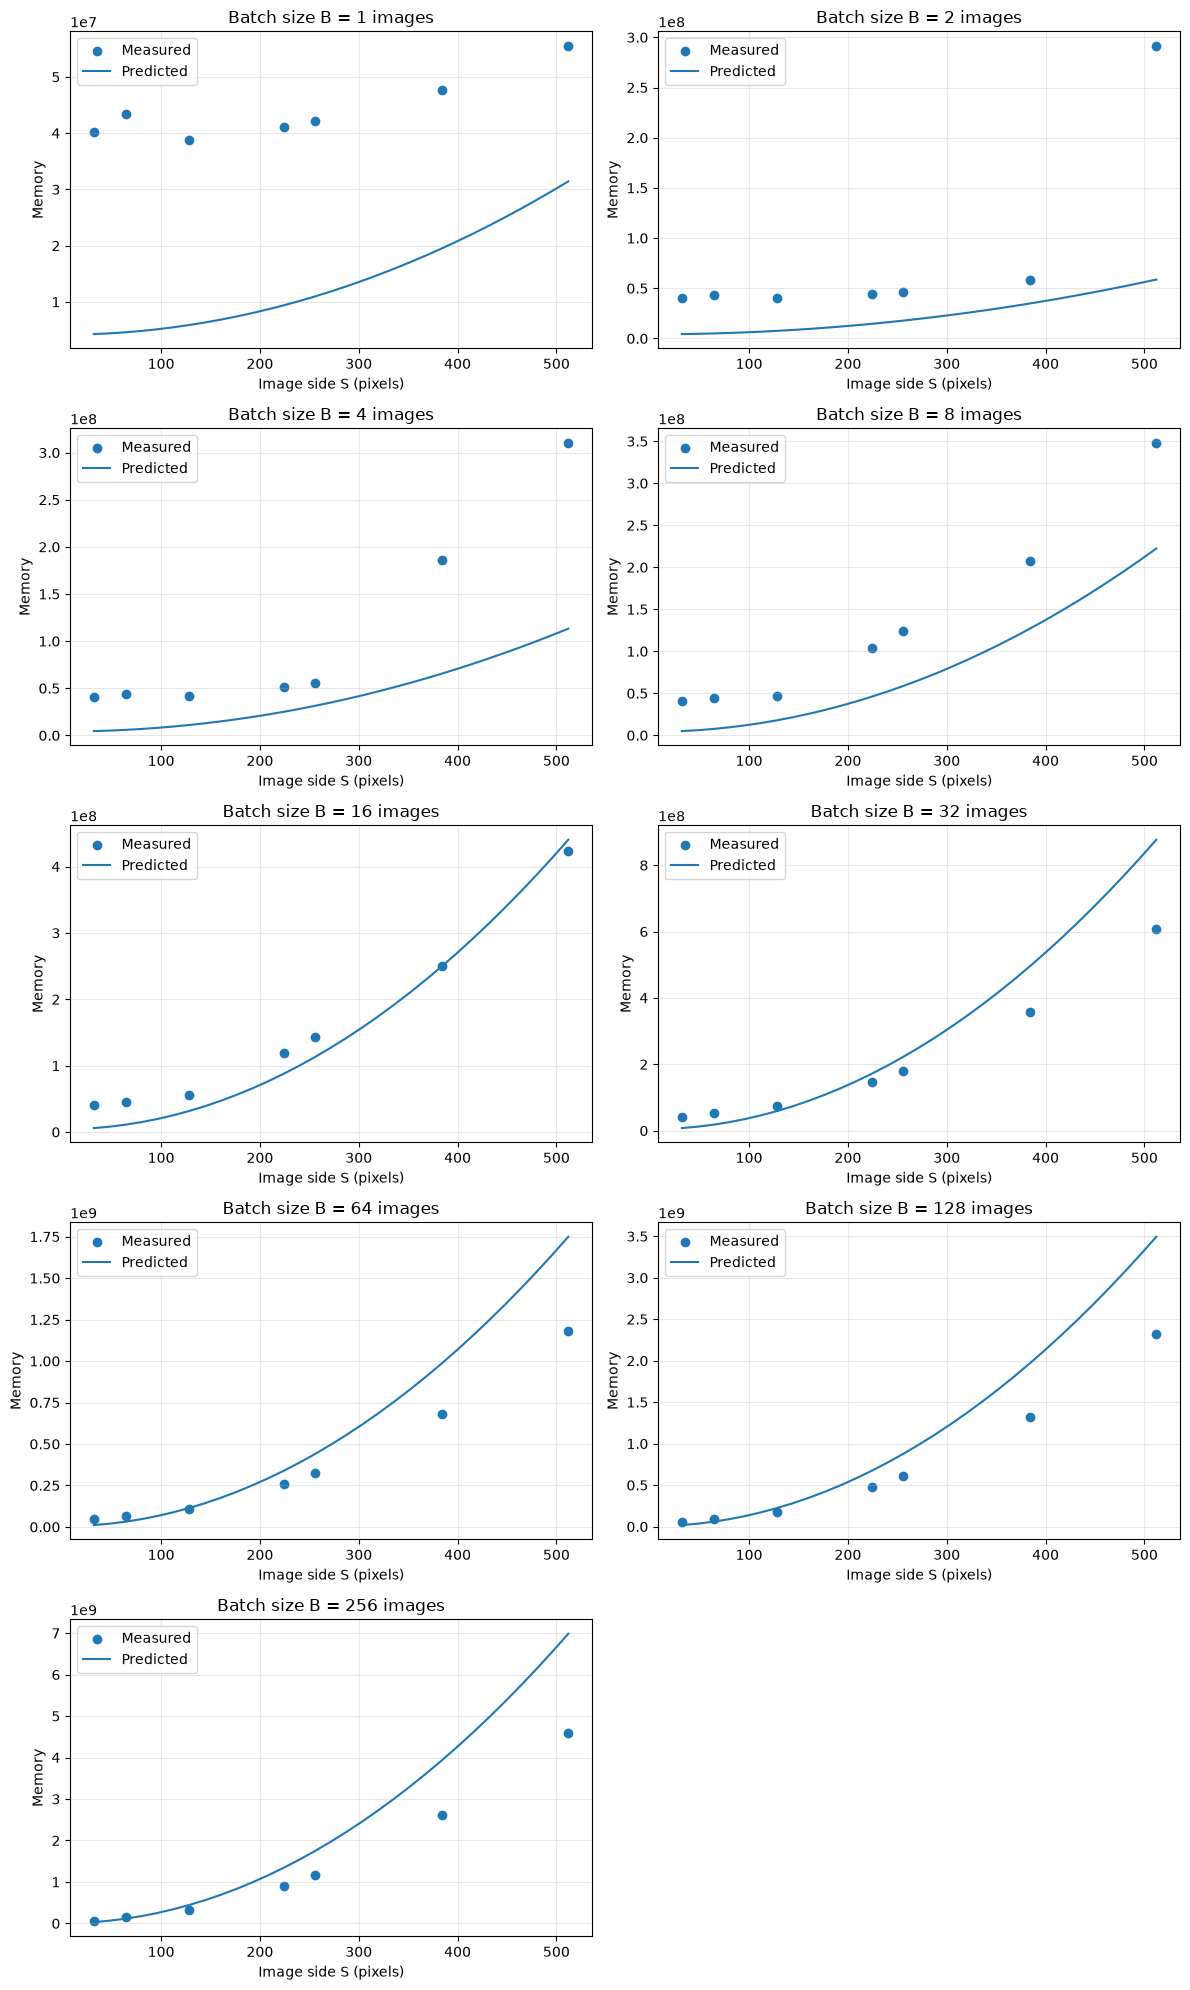

In [9]:
memory_rows = collect_measurements(model, sizes, batch_sizes, mode='memory')
measured_memory = memory_rows[:, 2]

predicted_memory = np.asarray(memory(sizes, batch_sizes), dtype=float)
relative_errors = (np.abs(predicted_memory - measured_memory) / measured_memory)

save_measurements_csv(PATH_CSV, sizes, batch_sizes, measured_memory, metric='memory')
print(f"Memory MAPE: {relative_errors.mean():.1%}")
plot(sizes, batch_sizes, measured_memory, memory, y_label='Memory', 
     path_save=f"{PATH_SAVE}/plot_memory.png")

## Latency

In [10]:
import json

path_teta = './results/theta.json'
with open(path_teta, "r", encoding="utf-8") as f:
    data = json.load(f)

theta_latency = data["theta_latency"]
theta_energy = data["theta_energy"]

Latency MAPE: 45.0%


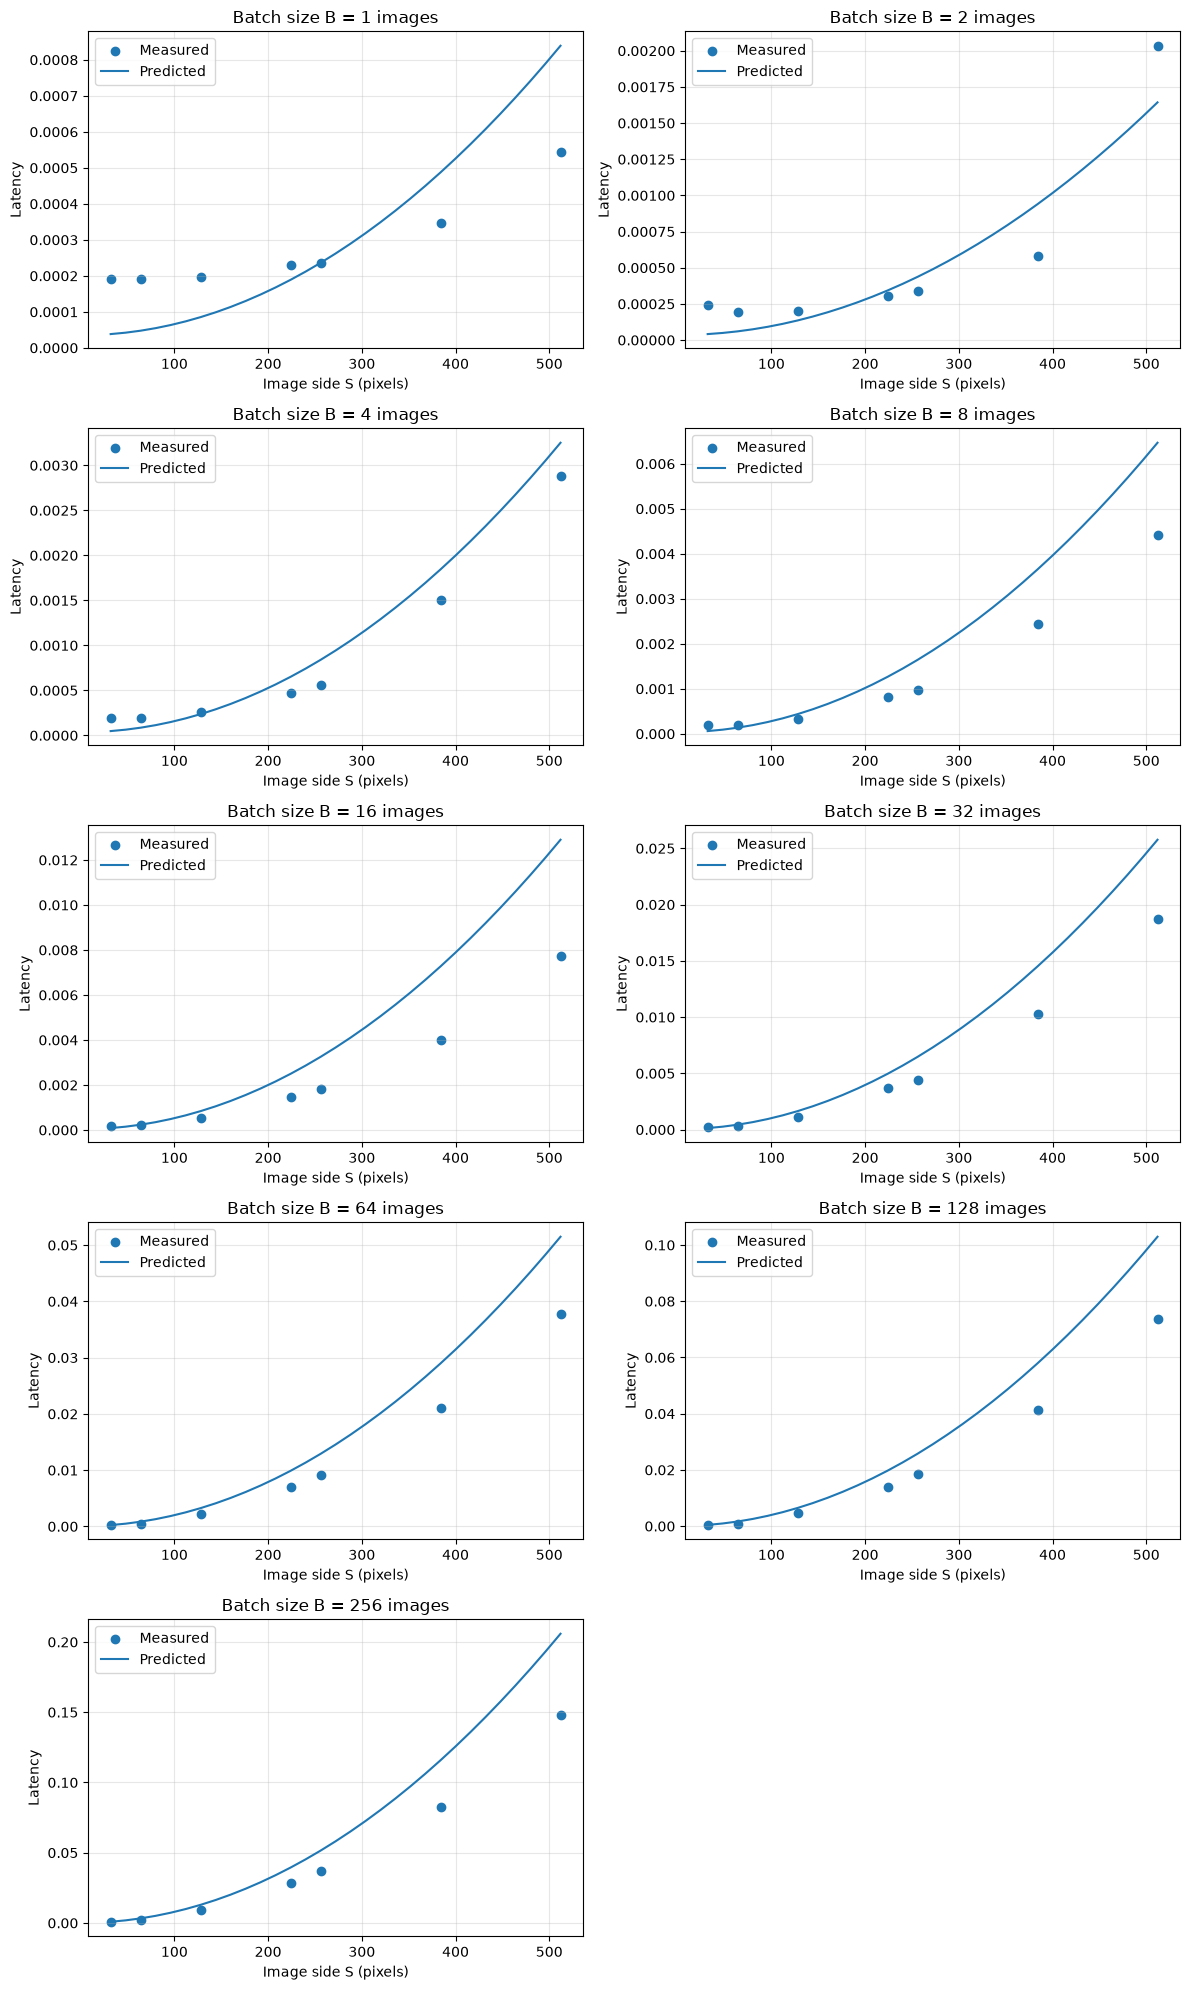

In [11]:
from hw1.equations import latency


latency_rows = collect_measurements(model, sizes, batch_sizes, mode='latency')
measured_latency = latency_rows[:, 2]

predicted_latency = np.asarray(latency(sizes, batch_sizes, theta_latency), dtype=float)
relative_errors = (np.abs(predicted_latency - measured_latency) / measured_latency)

save_measurements_csv(PATH_CSV, sizes, batch_sizes, measured_latency, metric='latency')
print(f"Latency MAPE: {relative_errors.mean():.1%}")
plot(sizes, batch_sizes, measured_latency, 
     lambda x, y: latency(x, y, theta_latency), y_label='Latency', 
     path_save=f"{PATH_SAVE}/plot_latency.png")

## Energy

Energy MAPE: 20.0%


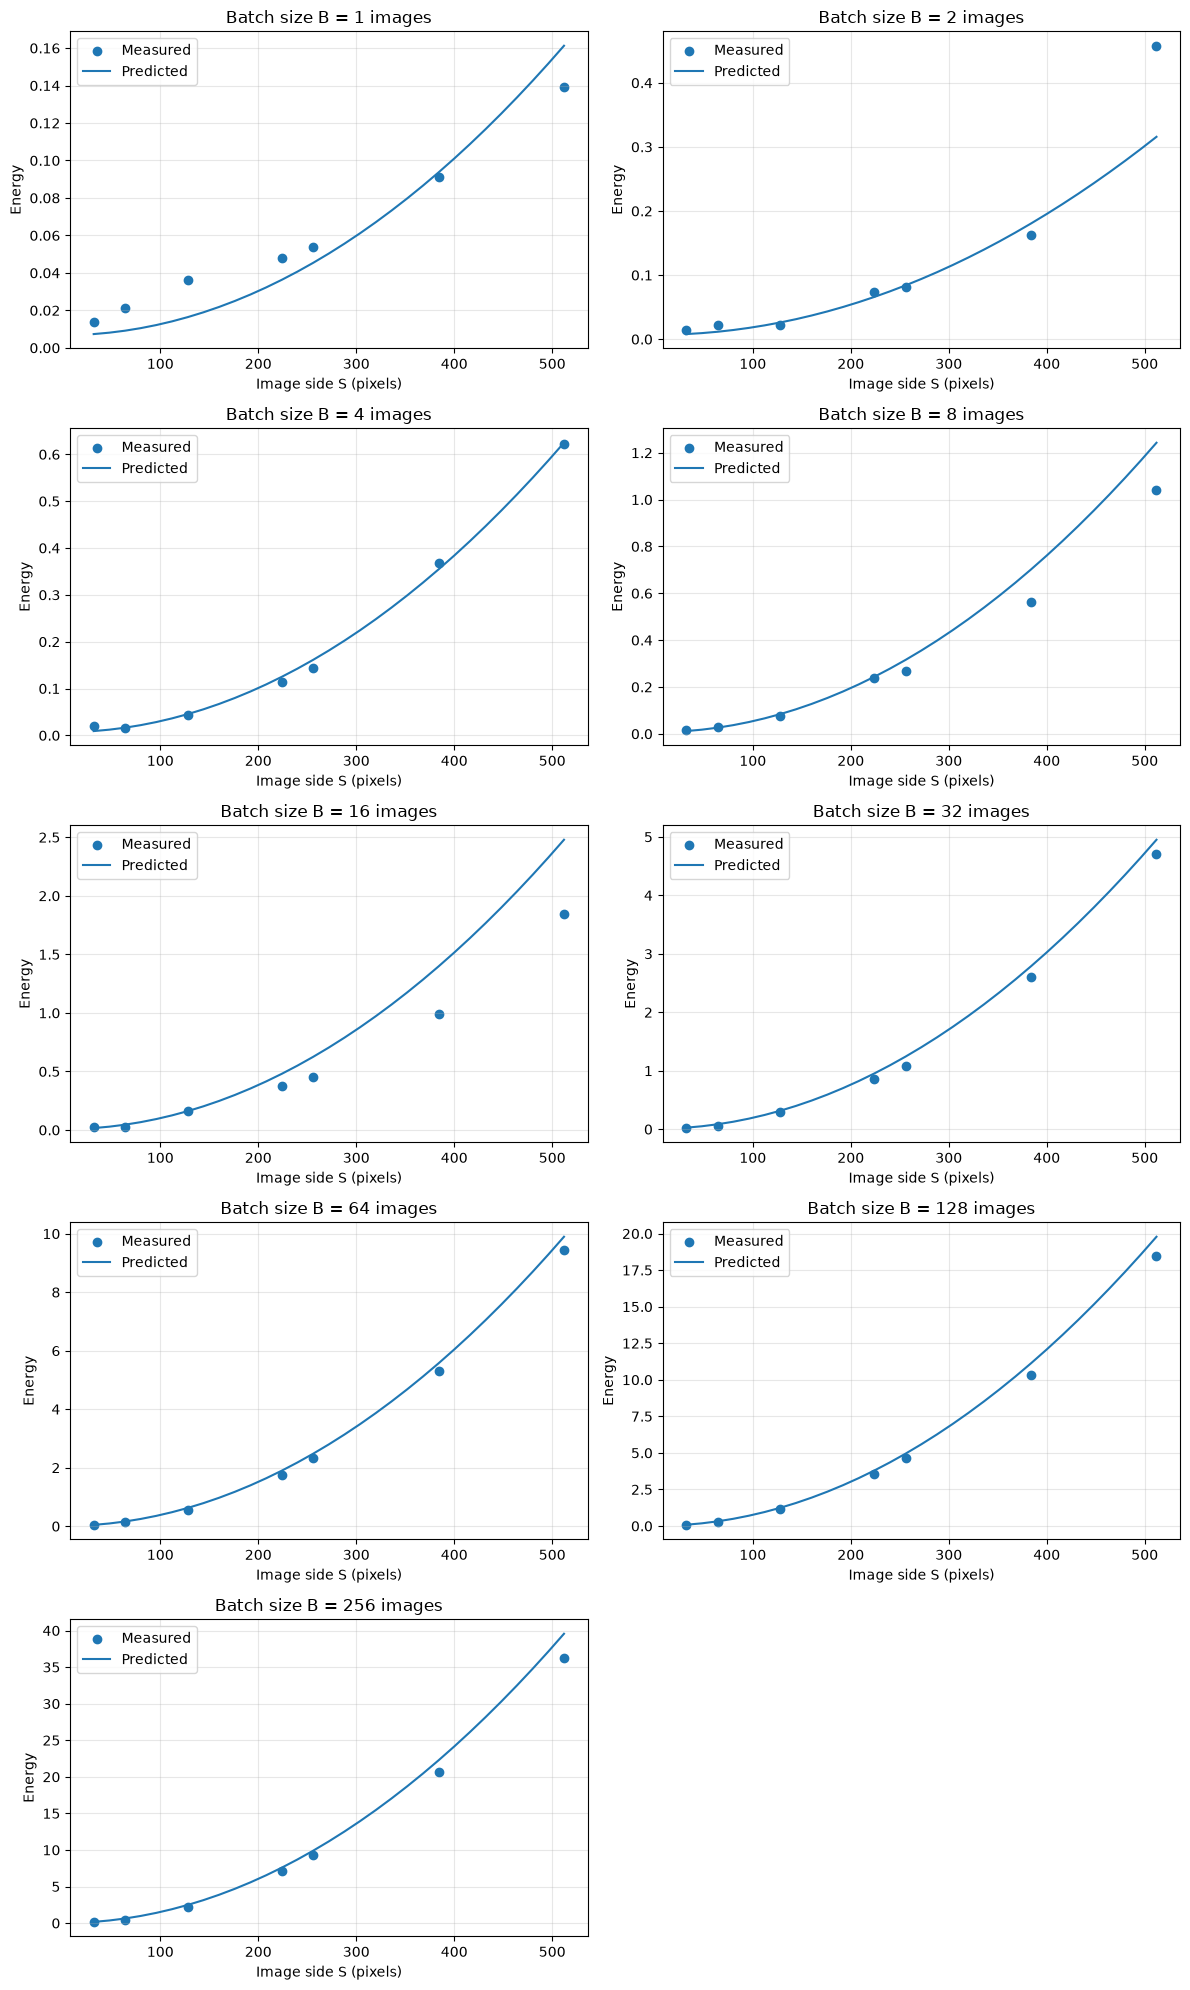

In [12]:
from hw1.equations import energy

pynvml.nvmlInit()

try:
    device = next(model.parameters()).device
    uuid = torch.cuda.get_device_properties(device).uuid
    if isinstance(uuid, bytes):
        uuid = uuid.decode()

    handle = pynvml.nvmlDeviceGetHandleByUUID(str(uuid))
    pynvml.nvmlDeviceGetTotalEnergyConsumption(handle)

    energy_rows = collect_measurements(model, sizes, batch_sizes, mode='energy', handle=handle, repeats=1000)
finally:
    pynvml.nvmlShutdown()

measured_energy = energy_rows[:, 2]

predicted_energy = np.asarray(energy(sizes, batch_sizes, theta_energy), dtype=float)
relative_errors = (np.abs(predicted_energy - measured_energy) / measured_energy)

save_measurements_csv(PATH_CSV, sizes, batch_sizes, measured_energy, metric='energy')
print(f"Energy MAPE: {relative_errors.mean():.1%}")
plot(sizes, batch_sizes, measured_energy, 
     lambda x, y: energy(x, y, theta_energy), y_label='Energy', 
     path_save=f"{PATH_SAVE}/plot_energy.png")